In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

# Create plots folder
os.makedirs("../outputs/plots", exist_ok=True)

In [6]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

movies.head()

Movies: (59234, 3)
Ratings: (124512, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")
print(f"Number of ratings: {num_ratings}")

Number of users: 611
Number of movies: 32918
Number of ratings: 124512


In [8]:
sparsity = 1 - (num_ratings / (num_users * num_movies))

print(f"Sparsity of dataset: {sparsity:.4f}")

Sparsity of dataset: 0.9938


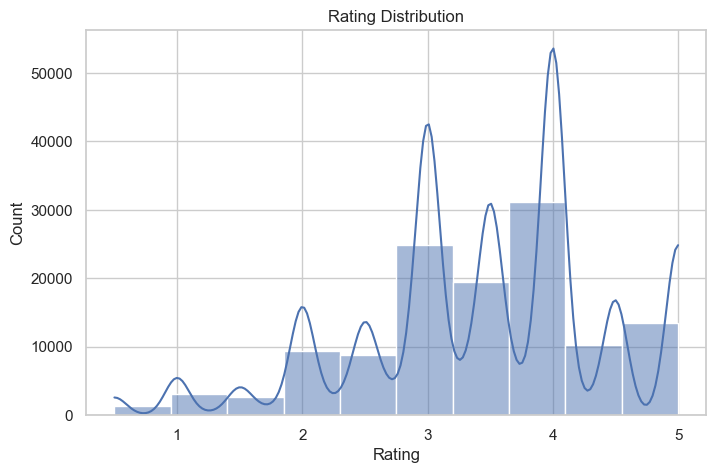

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("../outputs/plots/rating_distribution.png")
plt.show()

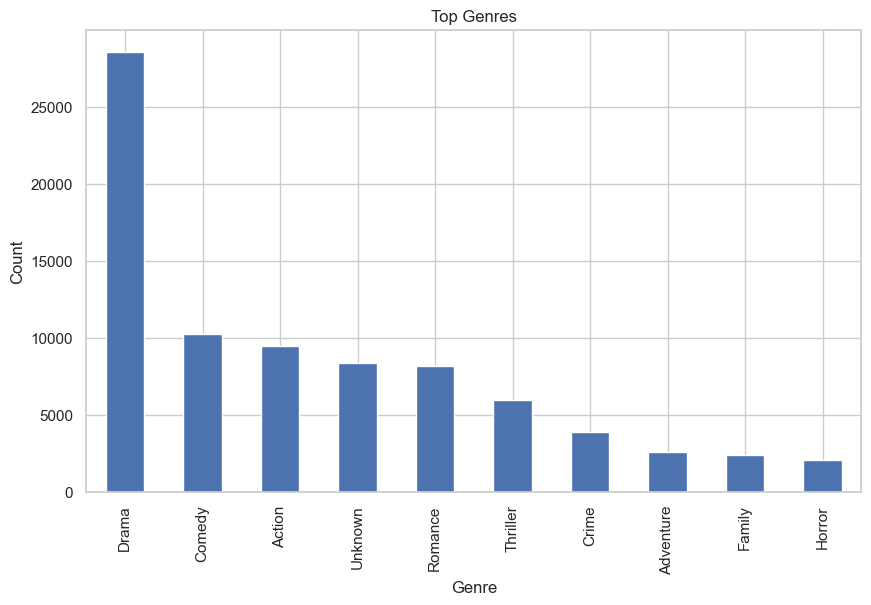

In [10]:
# Split genres
genres = movies['genres'].str.split('|')

# Flatten list
all_genres = [genre for sublist in genres for genre in sublist]

genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(10,6))
genre_counts.head(10).plot(kind='bar')

plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.savefig("../outputs/plots/top_genres.png")
plt.show()

In [11]:
movie_ratings_count = ratings.groupby('movieId').size().reset_index(name='count')

popular_movies = movie_ratings_count.merge(movies, on='movieId')

popular_movies = popular_movies.sort_values(by='count', ascending=False)

popular_movies.head(10)

,movieId,count,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


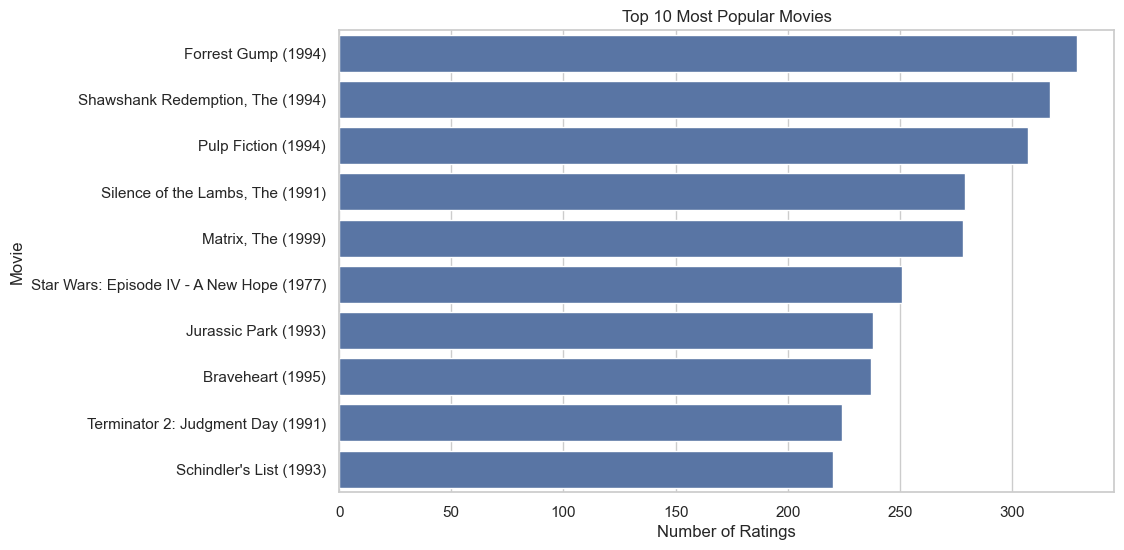

In [12]:
top_movies = popular_movies.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_movies, x='count', y='title')

plt.title("Top 10 Most Popular Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.savefig("../outputs/plots/popular_movies.png")
plt.show()

In [13]:
avg_rating = ratings.groupby('movieId')['rating'].mean().reset_index()

avg_rating_movies = avg_rating.merge(movies, on='movieId')

avg_rating_movies.sort_values(by='rating', ascending=False).head(10)

,movieId,rating,title,genres
7563,86237,5.0,Connections (1978),Documentary
5484,26366,5.0,Harlan County U.S.A. (1976),Documentary
4172,6021,5.0,"American Friend, The (Amerikanische Freund, De...",Crime|Drama|Mystery|Thriller
5490,26401,5.0,Last Hurrah for Chivalry (Hao xia) (1979),Action|Drama
22631,130151,5.0,Marasim - Beyond Borders,Short
7726,90943,5.0,Into the Abyss (2011),Documentary
2232,2969,5.0,"Man and a Woman, A (Un homme et une femme) (1966)",Drama|Romance
32410,152711,5.0,Who Killed Chea Vichea? (2010),Documentary
6393,50999,5.0,"Ugly Duckling and Me!, The (2006)",Animation|Comedy
7742,91355,5.0,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
